# WA-EVs: Matrix Completion Demonstration

Please note that this is a **demo only** notebook and the matrix completion was demonstrated on the scaled data rather than the raw data.

**Why demo-only?**

    Matrix completion is not part of our actual analysis pipeline. In a real workflow, missing values would be imputed before any scaling or log transforms. But in our project, the final county‑level dataset ended up fully complete after aggregation, so there was nothing to impute.

    We still wanted to show how matrix completion works, so this notebook artificailly creates a small missingness pattern and reconstructs it using low‑rank SVD. We apply the demo to the scaled dataset just because it matches the format used in our PCA and SVD sections. That is, the goal here is to illustrate the matrix completion method rather than modify the real data.

## Interpretation of the Results

After hiding 10% of the data, the SVD reconstruction did a surprisingly good job filling the gaps. The reconstruction error decreases as the rank increases, with the lowest RMSE at rank 5. This lines up closely with our PCA results, where the first five principal components explained over 90% of the variance in the dataset.

These latent factors likely correspond to broad structural patterns such as:
- EV adoption intensity
- Charger infrastructure availability
- County‑level socioeconomic characteristics
- Differences between BEV‑dominant and PHEV‑dominant regions

The dataset has a lot of internal structure, and counties that behave similarly in one EV‑related metric tend to behave similarly in others. Therefore, the model can “guess” missing values pretty well. Although we didn’t actually need to impute anything in our real dataset, this demo shows that matrix completion would have worked if we had missing values.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir(r"C:\Users\alexm\Documents\GitHub\SML_group_project")
print("Working directory:", os.getcwd())

Working directory: C:\Users\alexm\Documents\GitHub\SML_group_project


In [3]:
# Load scaled county data
mc_df = pd.read_csv('data/county_scaled.csv')
print('county_scaled shape:', mc_df.shape)
display(mc_df.head(10))

county_scaled shape: (39, 25)


,county,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age,percent_BEV,percent_PHEV,BEV_to_PHEV_ratio,...,fast_charger_share,chargers_per_1000_EV,total_EV_count_log,BEV_count_log,PHEV_count_log,total_chargers_log,level1_chargers_log,level2_chargers_log,dc_fast_chargers_log,chargers_per_1000_EV_log
0,ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146,0.167054,-0.164494,-0.056726,...,2.701390,1.016734,-1.114216,-1.056557,-1.189832,-0.650199,-0.354030,-1.817486,0.251486,1.534355
1,ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187,-0.587885,0.589688,-0.825894,...,-0.849210,-0.369807,-1.047830,-1.038530,-1.017391,-1.403685,-0.354030,-1.146074,-1.099162,-0.357901
2,BENTON,-0.151110,-0.162655,-0.105280,0.102907,0.097750,-0.102907,-0.033466,0.035825,-0.291918,...,0.334323,-0.468077,0.649723,0.626235,0.710560,0.304856,-0.354030,0.281179,0.527180,-0.688372
3,CHELAN,-0.238788,-0.228926,-0.276742,0.693473,1.306427,-0.693473,1.161181,-1.157625,1.672837,...,0.349117,0.243146,0.249647,0.307819,0.080535,0.658957,2.363072,0.620363,0.855439,0.797796
4,CLALLAM,-0.234705,-0.235840,-0.229491,-1.035965,-0.557642,1.035965,-0.215862,0.218038,-0.484569,...,0.351728,0.056492,0.277632,0.257791,0.340796,0.558610,-0.354030,0.522370,0.765017,0.537893
5,CLARK,0.395603,0.343343,0.599608,0.511223,-0.033929,-0.511223,0.451463,-0.448618,0.327704,...,0.273000,-0.477989,1.384986,1.360598,1.417366,1.205565,-0.354030,1.171228,1.321728,-0.726681
6,COLUMBIA,-0.307265,-0.296520,-0.348471,0.204913,1.907876,-0.204913,1.143948,-1.140409,1.631087,...,-0.405385,5.452998,-1.794996,-1.656809,-2.074941,-0.716138,-0.354030,-0.546645,-0.692577,3.190477
7,COWLITZ,-0.247087,-0.243800,-0.259202,0.401482,0.071116,-0.401482,0.150558,-0.148015,-0.077097,...,1.560125,-0.327371,0.187322,0.192746,0.192833,0.016131,-0.354030,-0.410272,0.658071,-0.236917
8,DOUGLAS,-0.283090,-0.273957,-0.318863,0.089663,0.478783,-0.089663,0.683567,-0.757105,0.797031,...,-0.341982,-0.475425,-0.247336,-0.194949,-0.368649,-0.789850,-0.354030,-0.628252,-0.692577,-0.716665
9,FERRY,-0.306181,-0.295501,-0.347138,0.528969,2.410312,-0.528969,0.935187,-0.931858,1.167709,...,-0.849210,-0.703653,-1.453422,-1.339890,-1.676967,-2.091232,-0.354030,-1.817486,-1.099162,-2.165150


### 1. Extract Numeric Matrix

In [4]:
mc_county = mc_df.iloc[:, 0].copy()
mc_X = mc_df.iloc[:, 1:].copy()
mc_X_values = mc_X.values.copy()

print('Numeric matrix shape:', mc_X_values.shape)
print('Any missing values in original matrix?', np.isnan(mc_X_values).any())

Numeric matrix shape: (39, 24)
Any missing values in original matrix? False


### 2. Randomly Mask 10% of Entries

In [5]:
np.random.seed(64)

mc_mask_rate = 0.10
mc_mask = np.random.rand(*mc_X_values.shape) < mc_mask_rate

mc_observed = mc_X_values.copy()
mc_observed[mc_mask] = np.nan

print('Masked entries:', mc_mask.sum())
print('Mask percentage:', round(100 * mc_mask.mean(), 2), '%')

Masked entries: 108
Mask percentage: 11.54 %


In [6]:
# Missingness per column
missing_per_col = mc_mask.sum(axis=0)
print("Missing values per column:")
print(pd.Series(missing_per_col, index=mc_X.columns))

Missing values per column:
total_EV_count               7
BEV_count                    3
PHEV_count                   5
avg_model_year               2
avg_electric_range           5
avg_vehicle_age             10
percent_BEV                  3
percent_PHEV                 6
BEV_to_PHEV_ratio            2
median_income_2025           5
total_chargers               4
level1_chargers              4
level2_chargers              5
dc_fast_chargers             6
fast_charger_share           3
chargers_per_1000_EV         6
total_EV_count_log           1
BEV_count_log                4
PHEV_count_log               6
total_chargers_log           4
level1_chargers_log          3
level2_chargers_log          6
dc_fast_chargers_log         7
chargers_per_1000_EV_log     1
dtype: int64


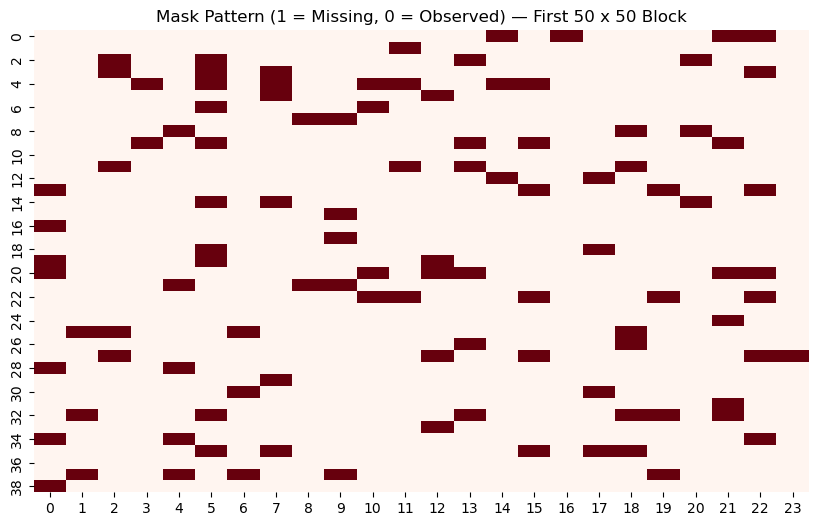

In [7]:
plt.figure(figsize=(10, 6))
sns.heatmap(mc_mask[:50, :50], cmap="Reds", cbar=False)
plt.title("Mask Pattern (1 = Missing, 0 = Observed) — First 50 x 50 Block")
plt.show()

### 3. Low-Rank SVD Reconstruction (Ranks 2-5)

In [8]:
def low_rank_recon(observed_matrix, rank):
    # Fill missing values with column means first
    col_means = np.nanmean(observed_matrix, axis=0)
    filled = np.where(np.isnan(observed_matrix), col_means, observed_matrix)

    # SVD and rank-r reconstruction
    U, s, Vt = np.linalg.svd(filled, full_matrices=False)
    U_r = U[:, :rank]
    S_r = np.diag(s[:rank])
    Vt_r = Vt[:rank, :]

    reconstructed = U_r @ S_r @ Vt_r
    return reconstructed

In [9]:
# Baseline: column-mean imputation
col_means = np.nanmean(mc_observed, axis=0)
baseline_pred = np.tile(col_means, (mc_X_values.shape[0], 1))
baseline_rmse = np.sqrt(np.mean((mc_X_values[mc_mask] - baseline_pred[mc_mask]) ** 2))

print("Baseline RMSE (column means only):", baseline_rmse)

Baseline RMSE (column means only): 1.011257524074002


In [10]:
# ranks 2-5
mc_ranks = [2, 3, 4, 5] 
mc_rmse_rows = []
mc_reconstructions = {}

for r in mc_ranks:
    recon = low_rank_recon(mc_observed, rank=r)
    mc_reconstructions[r] = recon

    # Evaluate only where data was masked
    true_vals = mc_X_values[mc_mask]
    pred_vals = recon[mc_mask]
    rmse = np.sqrt(np.mean((true_vals - pred_vals) ** 2))

    mc_rmse_rows.append({'rank': r, 'rmse_on_masked_entries': rmse})

mc_rmse_table = pd.DataFrame(mc_rmse_rows)
display(mc_rmse_table)

,rank,rmse_on_masked_entries
0,2,0.863003
1,3,0.860260
2,4,0.827120
3,5,0.806959


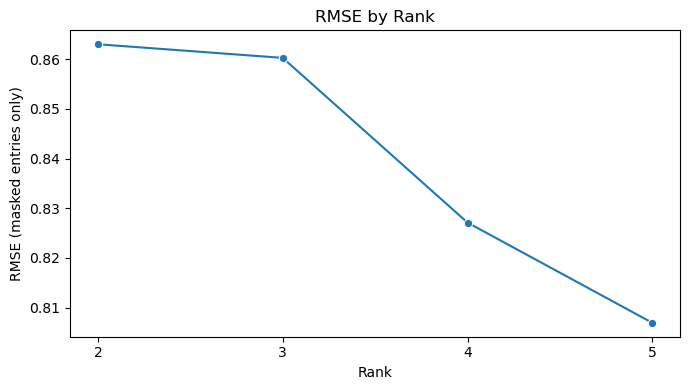

In [11]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=mc_rmse_table, x='rank', y='rmse_on_masked_entries', marker='o')
plt.title('RMSE by Rank')
plt.xlabel('Rank')
plt.ylabel('RMSE (masked entries only)')
plt.xticks(mc_ranks)
plt.tight_layout()
plt.show()

### 4. Before & After Comparison (Sample Rows)

In [12]:
# Show a compact comparison for a few rows
mc_best_rank = int(mc_rmse_table.sort_values('rmse_on_masked_entries').iloc[0]['rank'])
mc_best_recon = mc_reconstructions[mc_best_rank]

mc_sample_rows = [0, 1, 2, 3, 4]
mc_sample_cols = list(range(min(6, mc_X_values.shape[1])))

mc_original_sample = pd.DataFrame(
    mc_X_values[np.ix_(mc_sample_rows, mc_sample_cols)],
    index=mc_county.iloc[mc_sample_rows],
    columns=mc_X.columns[mc_sample_cols]
)

mc_observed_sample = pd.DataFrame(
    mc_observed[np.ix_(mc_sample_rows, mc_sample_cols)],
    index=mc_county.iloc[mc_sample_rows],
    columns=mc_X.columns[mc_sample_cols]
)

mc_recon_sample = pd.DataFrame(
    mc_best_recon[np.ix_(mc_sample_rows, mc_sample_cols)],
    index=mc_county.iloc[mc_sample_rows],
    columns=mc_X.columns[mc_sample_cols]
)

print(f'Best rank by RMSE: {mc_best_rank}')
print('\nOriginal values:')
display(mc_original_sample)

print('\nObserved matrix after masking (NaN = hidden values):')
display(mc_observed_sample)

print('\nReconstructed values (best rank):')
display(mc_recon_sample)

Best rank by RMSE: 5

Original values:


,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age
county,,,,,,
ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146
ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187
BENTON,-0.151110,-0.162655,-0.105280,0.102907,0.097750,-0.102907
CHELAN,-0.238788,-0.228926,-0.276742,0.693473,1.306427,-0.693473
CLALLAM,-0.234705,-0.235840,-0.229491,-1.035965,-0.557642,1.035965



Observed matrix after masking (NaN = hidden values):


,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age
county,,,,,,
ADAMS,-0.304028,-0.293785,-0.343275,0.351146,0.321535,-0.351146
ASOTIN,-0.303403,-0.293637,-0.340779,-0.335187,-0.796852,0.335187
BENTON,-0.151110,-0.162655,NaN,0.102907,0.097750,NaN
CHELAN,-0.238788,-0.228926,NaN,0.693473,1.306427,NaN
CLALLAM,-0.234705,-0.235840,-0.229491,NaN,-0.557642,NaN



Reconstructed values (best rank):


,total_EV_count,BEV_count,PHEV_count,avg_model_year,avg_electric_range,avg_vehicle_age
county,,,,,,
ADAMS,-0.146664,-0.323453,-0.395848,0.532893,0.489398,-0.420671
ASOTIN,-0.228220,-0.304893,-0.348256,-0.368939,-0.447569,0.273729
BENTON,0.155369,-0.057292,-0.010843,-0.052877,-0.284476,0.012297
CHELAN,0.028951,0.296576,0.287467,0.315829,1.054484,-0.182385
CLALLAM,0.072761,-0.108764,-0.091955,0.080682,-0.363923,-0.083655
